In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import country_converter as cc
import seaborn as sns

df = pd.read_csv("WHR_2023.csv")
df["Continent"] = cc.convert(names=df["Country name"].tolist(), to="continent")
df

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Continent
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363,Europe
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084,Europe
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250,Europe
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691,Asia
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),3.207,0.095,3.394,3.020,7.007,0.652,55.375,0.664,0.086,0.834,1.778,0.531,0.784,0.105,0.375,0.183,0.068,1.162,Africa
133,Zimbabwe,3.204,0.061,3.323,3.084,7.641,0.690,54.050,0.654,-0.046,0.766,1.778,0.758,0.881,0.069,0.363,0.112,0.117,0.905,Africa
134,Sierra Leone,3.138,0.082,3.299,2.976,7.394,0.555,54.900,0.660,0.105,0.858,1.778,0.670,0.540,0.092,0.371,0.193,0.051,1.221,Africa
135,Lebanon,2.392,0.044,2.479,2.305,9.478,0.530,66.149,0.474,-0.141,0.891,1.778,1.417,0.476,0.398,0.123,0.061,0.027,-0.110,Asia


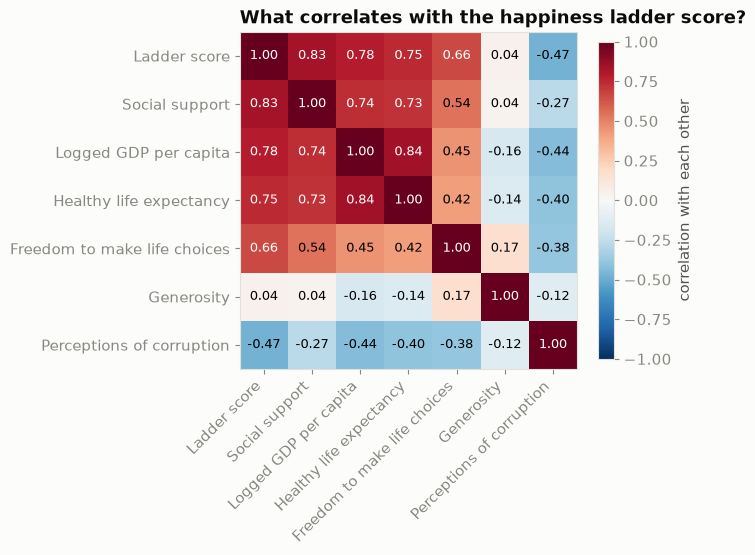

Ladder score                    1.000
Social support                  0.835
Logged GDP per capita           0.784
Healthy life expectancy         0.747
Freedom to make life choices    0.663
Generosity                      0.044
Perceptions of corruption      -0.472
Name: Ladder score, dtype: float64


In [17]:
factors = [
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption",
]

corr = df[factors].corr()
order = corr["Ladder score"].sort_values(ascending=False).index
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.grid(False)

for i in range(len(order)):
    for j in range(len(order)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.55 else "black", fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("correlation with each other")
ax.set_title("What correlates with the happiness ladder score?", loc="left", fontweight="bold")
fig.tight_layout()
plt.show()

print(corr["Ladder score"].round(3))

<function matplotlib.pyplot.show(close=None, block=None)>

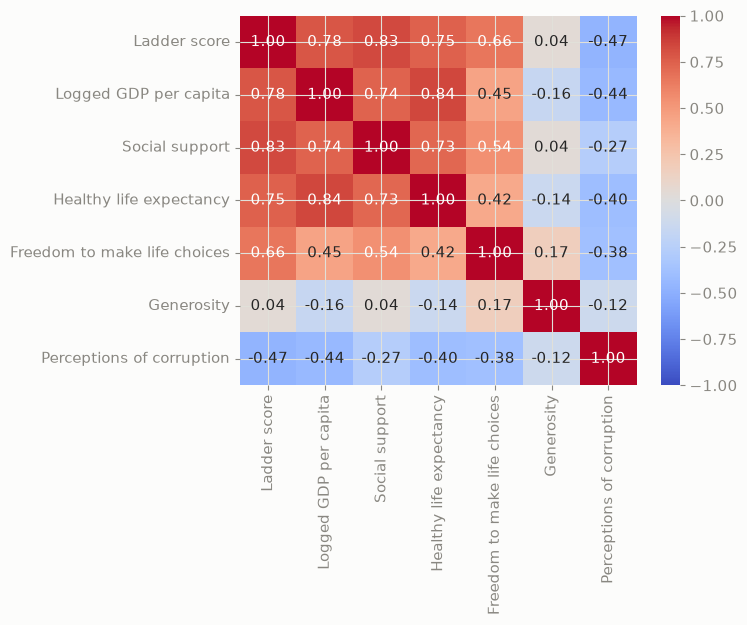

In [18]:
corr = df[factors].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show

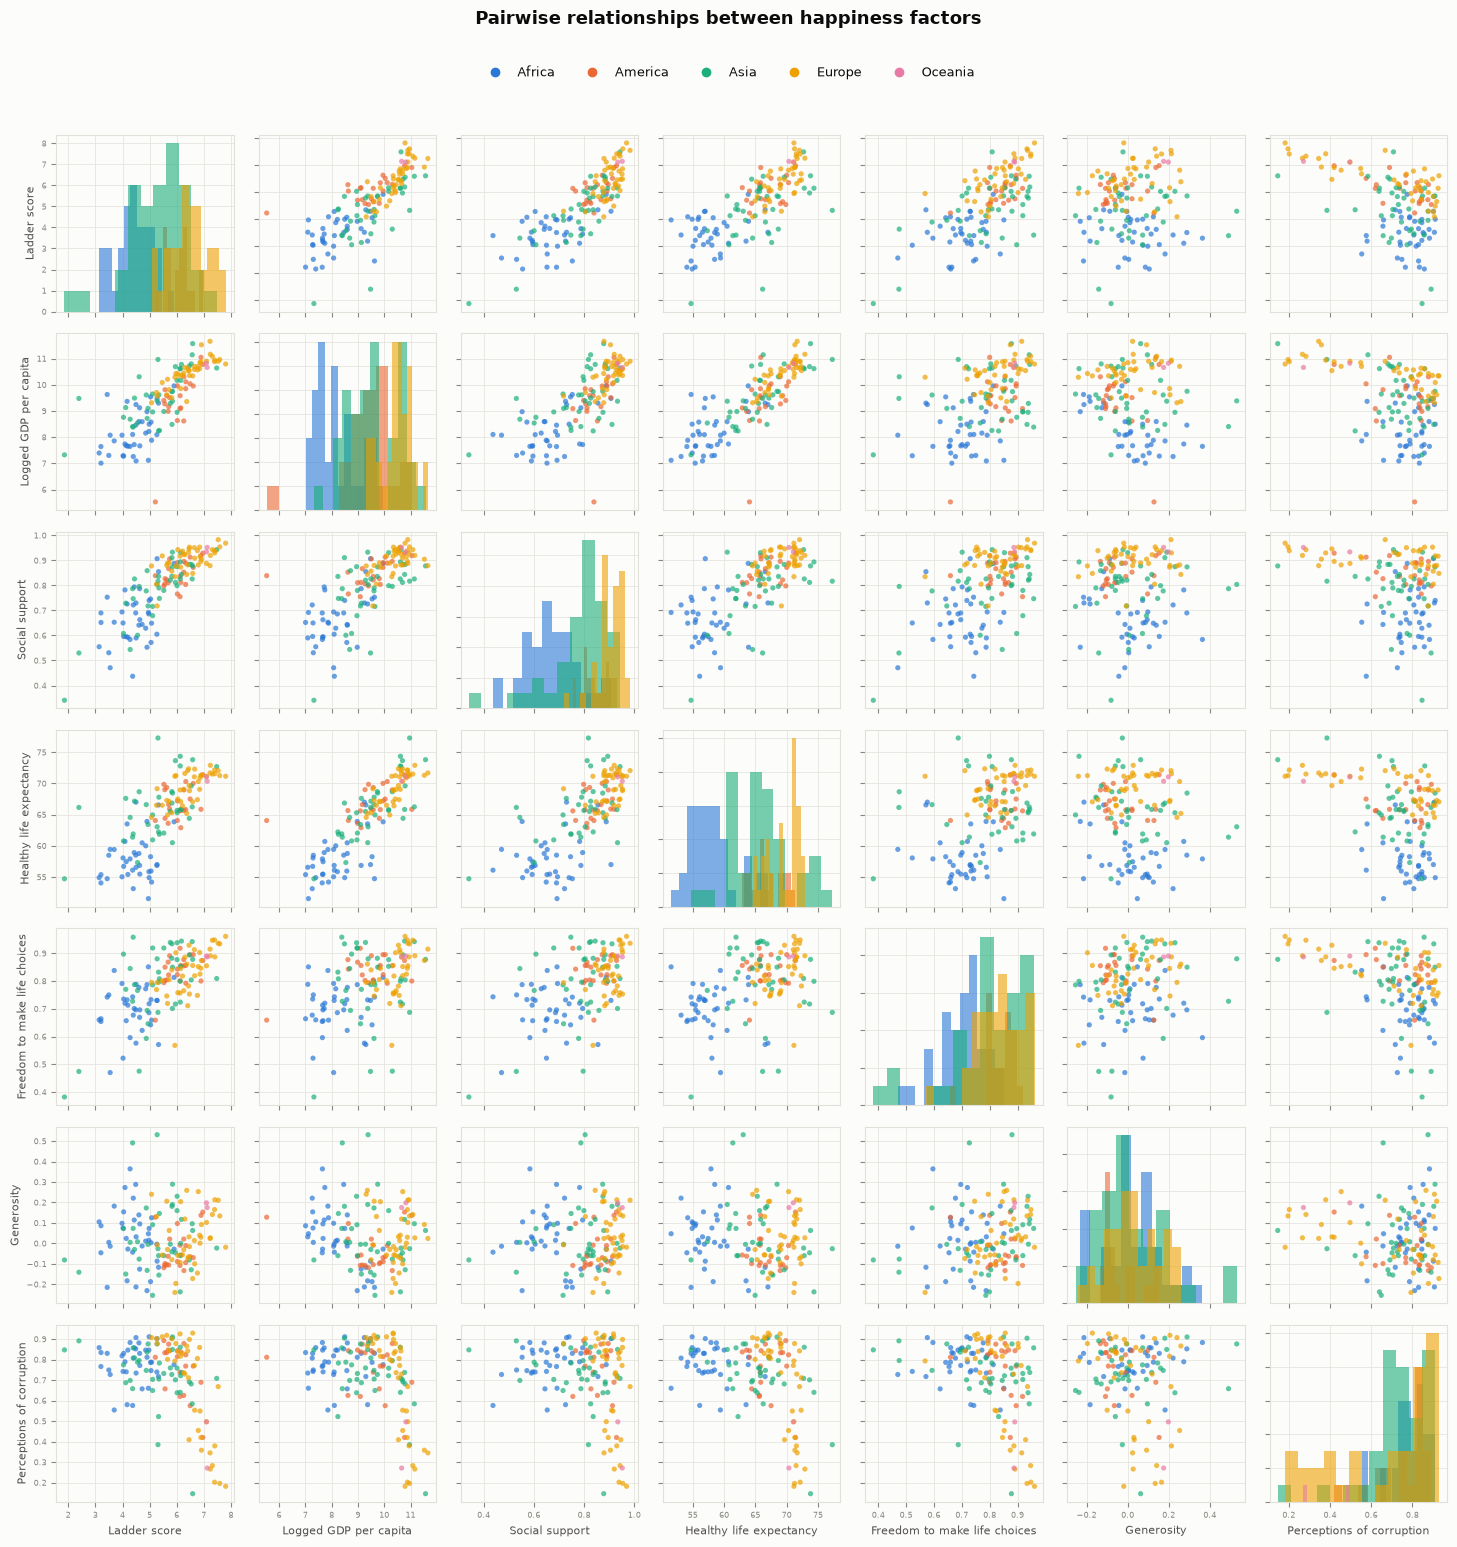

In [19]:
continent_colors = {
    "Africa": "#2a78d6",
    "America": "#eb6834",
    "Asia": "#1baf7a",
    "Europe": "#eda100",
    "Oceania": "#e87ba4",
}

n = len(factors)
fig, axes = plt.subplots(n, n, figsize=(2.1 * n, 2.1 * n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        row, col = factors[i], factors[j]

        if i == j:
            for continent, color in continent_colors.items():
                vals = df.loc[df["Continent"] == continent, col]
                ax.hist(vals, bins=12, color=color, alpha=0.6, edgecolor="none")
        else:
            for continent, color in continent_colors.items():
                sub = df[df["Continent"] == continent]
                ax.scatter(sub[col], sub[row], s=14, color=color, alpha=0.7,
                           edgecolors="none")

        ax.tick_params(labelsize=6)
        ax.grid(color="#e1e0d9", linewidth=0.5)
        ax.set_axisbelow(True)

        if i == n - 1:
            ax.set_xlabel(col, fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(row, fontsize=8)
        else:
            ax.set_yticklabels([])

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=cont)
           for cont, c in continent_colors.items()]
fig.legend(handles=handles, loc="upper center", ncol=len(continent_colors),
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=9)

fig.suptitle("Pairwise relationships between happiness factors", y=1.05,
             fontweight="bold")
fig.tight_layout()
plt.show()

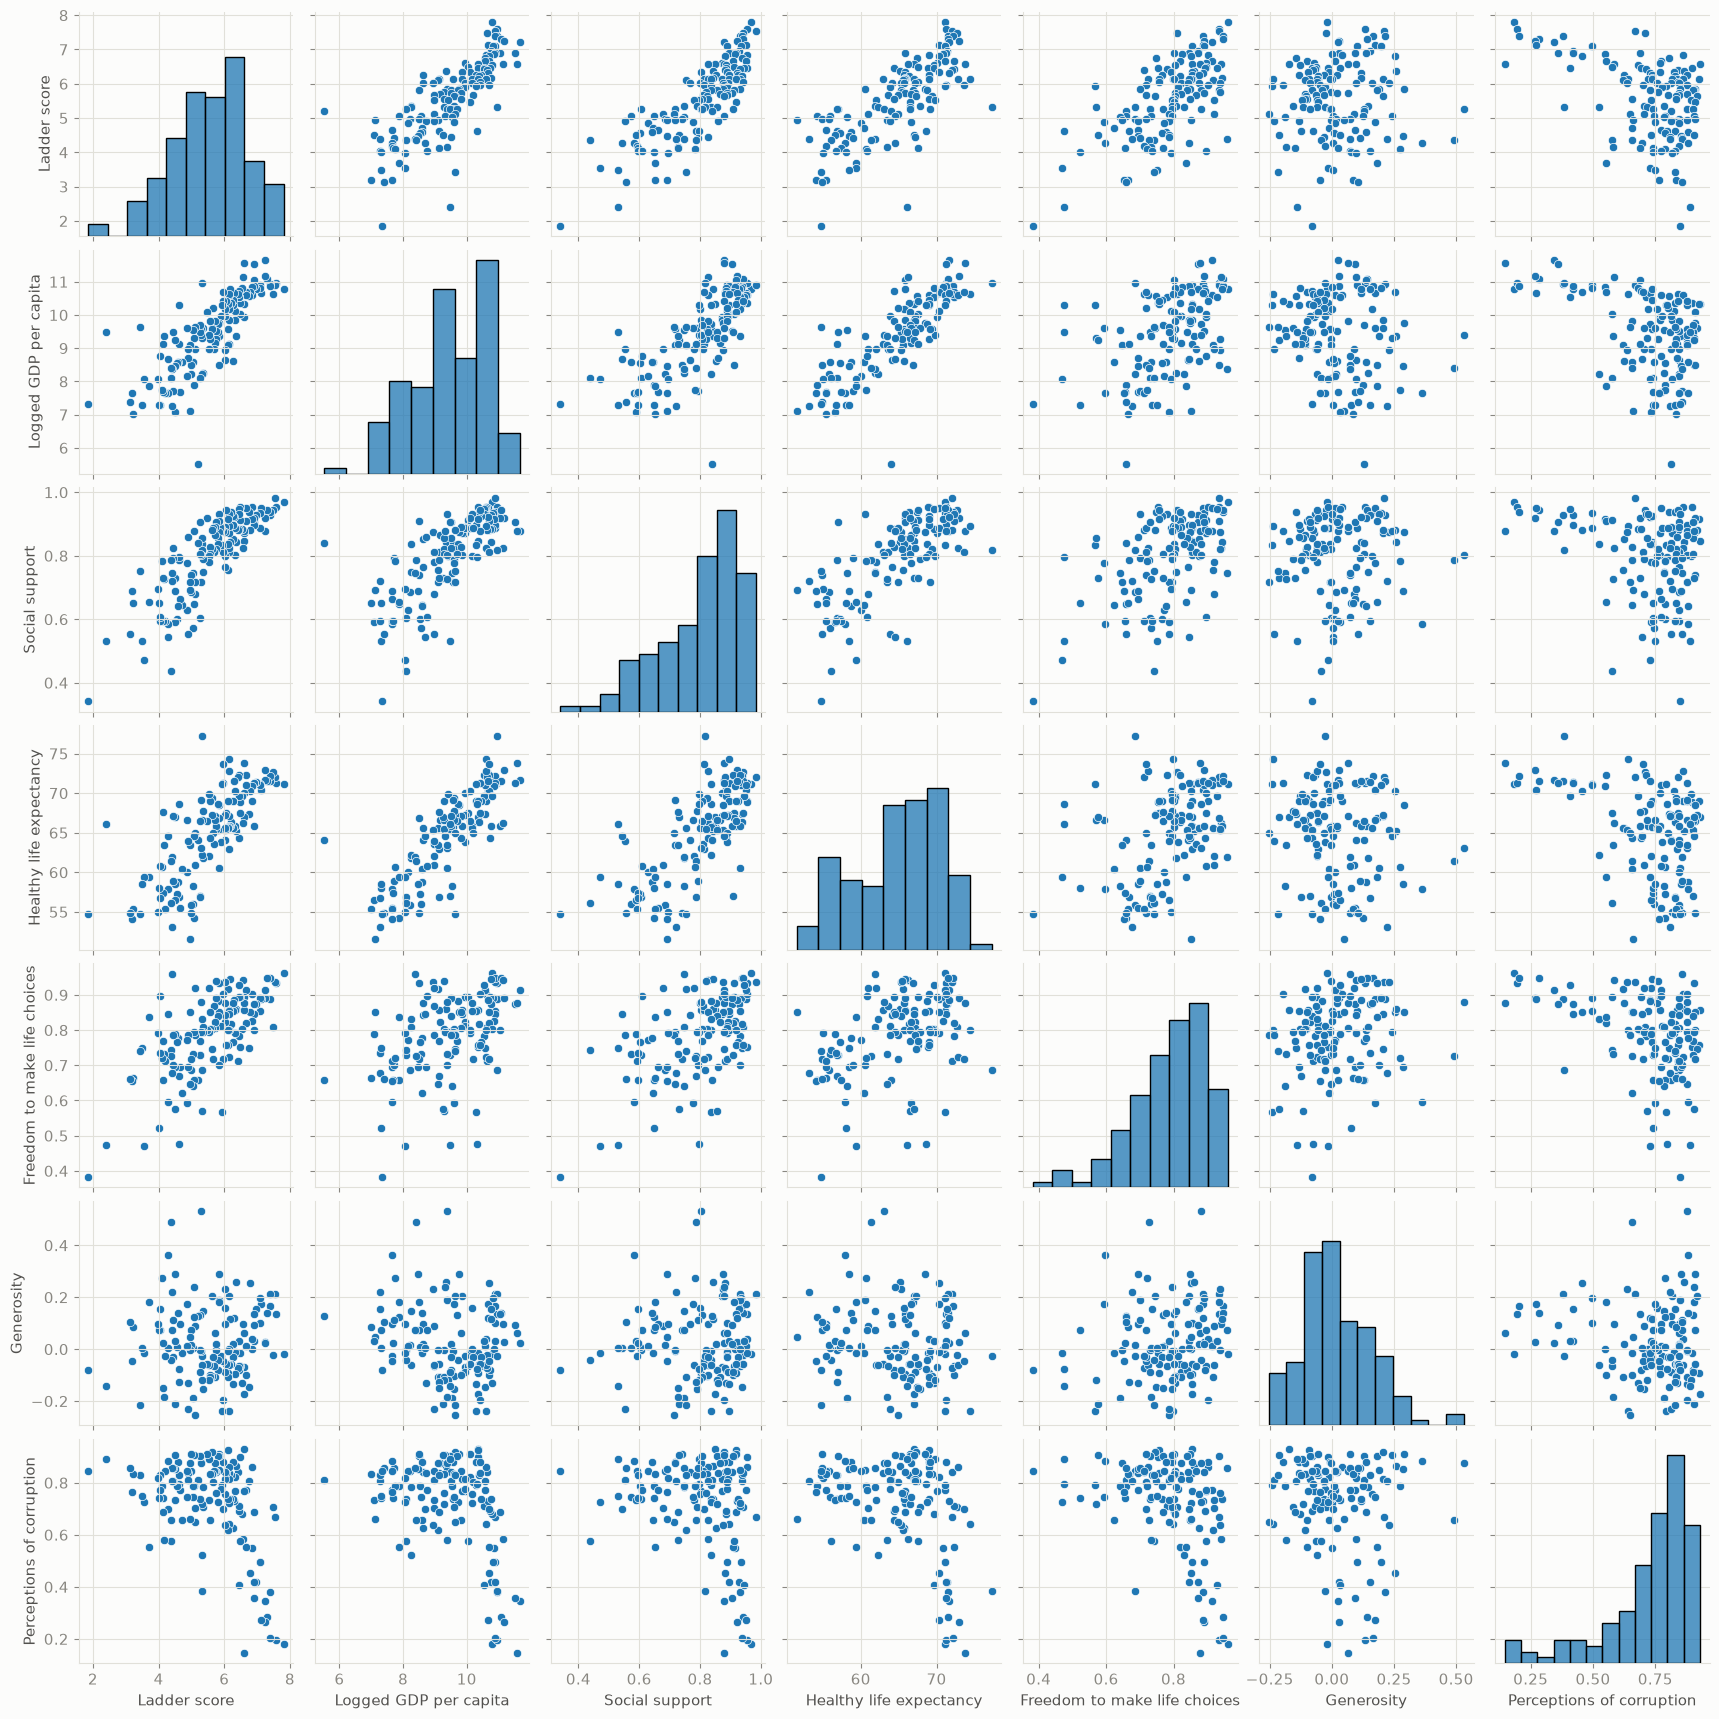

In [20]:
sns.pairplot(df[factors])